In [1]:
from itertools import combinations
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
EMNLP_RC = {
    'font.family': 'serif',
    'font.serif': [
        'Times New Roman', 'Times', 'Nimbus Roman No9 L',
        'TeX Gyre Termes', 'DejaVu Serif',
    ],
    'mathtext.fontset': 'stix',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
}

In [2]:
def find_inference_parquet_paths(root_dir: str | Path) -> list[Path]:
    """Recursively collect .parquet paths under root_dir.

    Keeps files whose immediate parent directory is named ``inference`` and
    whose filename does not contain ``9b`` or ``l20``.
    """
    root = Path(root_dir)

    paths: list[Path] = []
    for path in root.rglob("steering_data.parquet"):
        if path.parent.name != "evaluate":
            continue
        
        paths.append(path)

    return sorted(paths)

In [3]:
file_paths = find_inference_parquet_paths('./main_results/T1-results')
result_df = {'Method': [], 'Model': [], 'Layer': [], 'Score': []}
for fp in file_paths:
    temp = pd.read_parquet(str(fp))
    model = str(fp).split('/')[2]
    layer = str(fp).split('/')[3]
    method = str(fp).split('/')[4]
    if method == 'dpo':
        temp.columns = temp.columns.str.replace('GemmaScopeSAE', 'DPO', regex=False)
        temp.columns = temp.columns.str.replace('LoRa', 'DPO', regex=False)
        temp.columns = temp.columns.str.replace('LoRA', 'DPO', regex=False)
        temp.columns = temp.columns.str.replace('LoReFT', 'DPO', regex=False)
        temp.columns = temp.columns.str.replace('PromptSteering', 'DPO', regex=False)
    scores_columns = temp.columns[temp.columns.str.endswith('_LMJudgeEvaluator')]
    means = temp[scores_columns].mean(axis=0).to_list()
    for i, (m, n) in enumerate(zip(means, scores_columns)):
        result_df['Method'].append(n.split('_')[0])
        result_df['Model'].append(model)
        result_df['Layer'].append(layer)
        result_df['Score'].append(m)
result_df = pd.DataFrame(result_df)
result_df

,Method,Model,Layer,Score
0,DPO,2b,l10,0.938452
1,LoRA,2b,l10,0.545000
2,LoReFT,2b,l10,0.624405
3,DiffMean,2b,l10,0.124881
4,GemmaScopeSAE,2b,l10,0.108214
5,LAT,2b,l10,0.058452
6,PCA,2b,l10,0.027262
7,PromptSteering,2b,l10,0.748452
8,DPO,2b,l20,0.909881
9,LoRA,2b,l20,0.545476


In [4]:
file_paths = find_inference_parquet_paths('./main_results/T1-results')
qwens = []
for fp in file_paths:
    temp = pd.read_parquet(str(fp))
    model = str(fp).split('/')[2]
    layer = str(fp).split('/')[3]
    method = str(fp).split('/')[4]
    if (method == 'dpo') and (model == 'qwen3'):
        temp.columns = temp.columns.str.replace('GemmaScopeSAE', 'DPO', regex=False)
        temp.columns = temp.columns.str.replace('LoRa', 'DPO', regex=False)
        temp.columns = temp.columns.str.replace('LoRA', 'DPO', regex=False)
        temp.columns = temp.columns.str.replace('LoReFT', 'DPO', regex=False)
        temp.columns = temp.columns.str.replace('PromptSteering', 'DPO', regex=False)
        qwens.append(temp)
qwen_df = pd.concat(qwens, axis=0)
qwen_df


,dataset_name,concept_id,input_concept,input_id,factor,original_prompt,steered_input,input,suppress_original,suppress_rewrite,...,sae_id,DPO_steered_generation,DPO_perplexity,DPO_LMJudgeEvaluator_relevance_concept_ratings,DPO_LMJudgeEvaluator_relevance_instruction_ratings,DPO_LMJudgeEvaluator_fluency_ratings,DPO_LMJudgeEvaluator,DPO_LMJudgeEvaluator_relevance_concept_completions,DPO_LMJudgeEvaluator_relevance_instruction_completions,DPO_LMJudgeEvaluator_fluency_completions
0,AlpacaEval,0,Java programming framework and library referen...,0,0.2,What are different drawers I should have for c...,<|im_start|>user\nPlease generate responses th...,<|im_start|>user\nWhat are different drawers I...,,,...,4519,"I think to Hibernate, Spring, and Jackson\nI t...",10.497357,1.0,0.0,1.0,0.0,The concept of Java programming frameworks and...,The sentence fragment provided discusses organ...,The fluency of the provided sentence fragment ...
1,AlpacaEval,0,Java programming framework and library referen...,0,0.4,What are different drawers I should have for c...,<|im_start|>user\nPlease generate responses th...,<|im_start|>user\nWhat are different drawers I...,,,...,4519,"I think to Hibernate, Spring, and Jackson\nI t...",8.387175,1.0,0.0,1.0,0.0,The concept of Java programming frameworks and...,The sentence fragment provided discusses softw...,The fluency of the provided sentence fragment ...
2,AlpacaEval,0,Java programming framework and library referen...,0,0.6,What are different drawers I should have for c...,<|im_start|>user\nPlease generate responses th...,<|im_start|>user\nWhat are different drawers I...,,,...,4519,"I think to Hibernate, Spring, and Jackson\nI t...",9.731573,1.0,1.0,1.0,1.0,The concept of Java programming frameworks and...,The sentence fragment provided discusses vario...,The fluency of the provided sentence fragment ...
3,AlpacaEval,0,Java programming framework and library referen...,0,0.8,What are different drawers I should have for c...,<|im_start|>user\nPlease generate responses th...,<|im_start|>user\nWhat are different drawers I...,,,...,4519,"I think to Hibernate, Spring, and Jackson\nI t...",9.004237,1.0,0.0,1.0,0.0,The concept of Java programming frameworks and...,The sentence fragment provided discusses vario...,The fluency of the sentence fragment is hinder...
4,AlpacaEval,0,Java programming framework and library referen...,0,1.0,What are different drawers I should have for c...,<|im_start|>user\nPlease generate responses th...,<|im_start|>user\nWhat are different drawers I...,,,...,4519,"I think to Hibernate, Spring, and Jackson\nI t...",8.340899,1.0,0.0,1.0,0.0,The concept of Java programming frameworks and...,The sentence fragment provided discusses techn...,The fluency of the provided sentence fragment ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,AlpacaEval,19,concepts related to resilience and overcoming ...,2,2.0,I'm trying to stop my neighbour's cat from com...,"<|im_start|>user\nIn your responses, always in...",<|im_start|>user\nI'm trying to stop my neighb...,,,...,105642,I think I can help you navigate this situation...,4.950613,2.0,1.0,1.0,1.2,The concept of resilience and overcoming chall...,The sentence fragment provided discusses strat...,"The sentence fragment is generally fluent, wit..."
836,AlpacaEval,19,concepts related to resilience and overcoming ...,2,2.5,I'm trying to stop my neighbour's cat from com...,"<|im_start|>user\nIn your responses, always in...",<|im_start|>user\nI'm trying to stop my neighb...,,,...,105642,I think <think>\n\n</think>\n\nDealing with an...,3.906576,2.0,2.0,1.0,1.5,The concept of resilience and overcoming chall...,The sentence fragment discusses strategies for...,The fluency of the provided sentence fragment ...
837,AlpacaEval,19,concepts related to resilience and overcoming ...,2,3.0,I'm trying to stop my neighbour's cat from com...,"<|im_start|>user\nIn your responses, always in...",<|im_start|>user\nI'm trying to 

In [5]:
COLUMN_MAP = {
    ('2b', 'l10'): '2B L10',
    ('2b', 'l20'): '2B L20',
    ('9b', 'l20'): '9B L20',
    ('9b', 'l31'): '9B L31',
    ('llama_8b', 'l20'): '8B L20',
}
LATEX_COLUMNS = ['2B L10', '2B L20', '9B L20', '9B L31', '8B L20', 'Avg']
METHOD_ORDER = [
    'LAT', 'PCA', 'SAE', 'DiffMean', 'LoRA', 'LoReFT', 'PromptSteering', 'DPO',
]

table_df = result_df.copy()
table_df['Method'] = table_df['Method'].replace({'GemmaScopeSAE': 'SAE'})
table_df['Setting'] = table_df.apply(
    lambda r: COLUMN_MAP.get((r['Model'], r['Layer'])), axis=1
)
table_df = table_df.dropna(subset=['Setting'])

latex_table = (
    table_df.pivot(index='Method', columns='Setting', values='Score')
    .reindex(columns=LATEX_COLUMNS[:-1])
    .mul(100)
)
latex_table['Avg'] = latex_table.mean(axis=1)
latex_table = latex_table.reindex(METHOD_ORDER)

latex_table

Setting,2B L10,2B L20,9B L20,9B L31,8B L20,Avg
Method,,,,,,
LAT,5.845238,4.047619,3.130952,7.940476,1.178571,4.428571
PCA,2.726190,3.821429,3.380952,8.833333,0.821429,3.916667
SAE,10.821429,10.940476,5.273810,8.345238,NaN,8.845238
DiffMean,12.488095,6.226190,5.797619,6.571429,2.357143,6.688095
LoRA,54.500000,54.547619,55.142857,44.619048,NaN,52.202381
LoReFT,62.440476,56.940476,74.797619,58.773810,78.357143,66.261905
PromptSteering,74.845238,63.083333,101.809524,106.428571,114.809524,92.195238
DPO,93.845238,90.988095,104.130952,108.500000,99.428571,99.378571


In [6]:
def to_latex_rows(wide: pd.DataFrame) -> str:
    lines = []
    for method in METHOD_ORDER:
        if method not in wide.index:
            continue
        row = wide.loc[method]
        cells = [
            f"{row[col]:.1f}" if col in row and pd.notna(row[col]) else "--"
            for col in LATEX_COLUMNS
        ]
        lines.append(f"    {method} & " + " & ".join(cells) + r" \\")
    return "\n".join(lines)

print(to_latex_rows(latex_table))

    LAT & 5.8 & 4.0 & 3.1 & 7.9 & 1.2 & 4.4 \\
    PCA & 2.7 & 3.8 & 3.4 & 8.8 & 0.8 & 3.9 \\
    SAE & 10.8 & 10.9 & 5.3 & 8.3 & -- & 8.8 \\
    DiffMean & 12.5 & 6.2 & 5.8 & 6.6 & 2.4 & 6.7 \\
    LoRA & 54.5 & 54.5 & 55.1 & 44.6 & -- & 52.2 \\
    LoReFT & 62.4 & 56.9 & 74.8 & 58.8 & 78.4 & 66.3 \\
    PromptSteering & 74.8 & 63.1 & 101.8 & 106.4 & 114.8 & 92.2 \\
    DPO & 93.8 & 91.0 & 104.1 & 108.5 & 99.4 & 99.4 \\


In [9]:
file_paths = find_inference_parquet_paths('./main_results/T1-results')
result_df = {'Method': [], 'Model': [], 'Layer': [], 'Score_Concept': [], 'Score_Insturction': [], 'Score_Fluency': []}
for fp in file_paths:
    temp = pd.read_parquet(str(fp))
    model = str(fp).split('/')[2]
    layer = str(fp).split('/')[3]
    method = str(fp).split('/')[4]
    if method == 'dpo':
        temp.columns = temp.columns.str.replace('GemmaScopeSAE', 'DPO', regex=False)
        temp.columns = temp.columns.str.replace('LoRa', 'DPO', regex=False)
        temp.columns = temp.columns.str.replace('LoRA', 'DPO', regex=False)
        temp.columns = temp.columns.str.replace('LoReFT', 'DPO', regex=False)
    scores_columns = temp.columns[temp.columns.str.endswith('_ratings')].to_list()
    method_prefixes = sorted({c.split('_')[0] for c in scores_columns})
    for _, row in temp.iterrows():
        for method_name in method_prefixes:
            concept_col = next(
                c for c in scores_columns
                if c.startswith(f'{method_name}_') and 'concept' in c
            )
            instruction_col = next(
                c for c in scores_columns
                if c.startswith(f'{method_name}_') and 'instruction' in c
            )
            fluency_col = next(
                c for c in scores_columns
                if c.startswith(f'{method_name}_') and 'fluency' in c
            )
            result_df['Method'].append(method_name)
            result_df['Model'].append(model)
            result_df['Layer'].append(layer)
            result_df['Score_Concept'].append(row[concept_col])
            result_df['Score_Insturction'].append(row[instruction_col])
            result_df['Score_Fluency'].append(row[fluency_col])
    
result_df = pd.DataFrame(result_df)
result_df

,Method,Model,Layer,Score_Concept,Score_Insturction,Score_Fluency
0,DPO,2b,l10,0.0,2.0,2.0
1,DPO,2b,l10,2.0,2.0,1.0
2,DPO,2b,l10,1.0,1.0,1.0
3,DPO,2b,l10,2.0,2.0,2.0
4,DPO,2b,l10,2.0,2.0,1.0
...,...,...,...,...,...,...
36955,PromptSteering,qwen3,4b,2.0,1.0,1.0
36956,PromptSteering,qwen3,4b,1.0,1.0,1.0
36957,PromptSteering,qwen3,4b,1.0,1.0,1.0
36958,PromptSteering,qwen3,4b,2.0,1.0,1.0


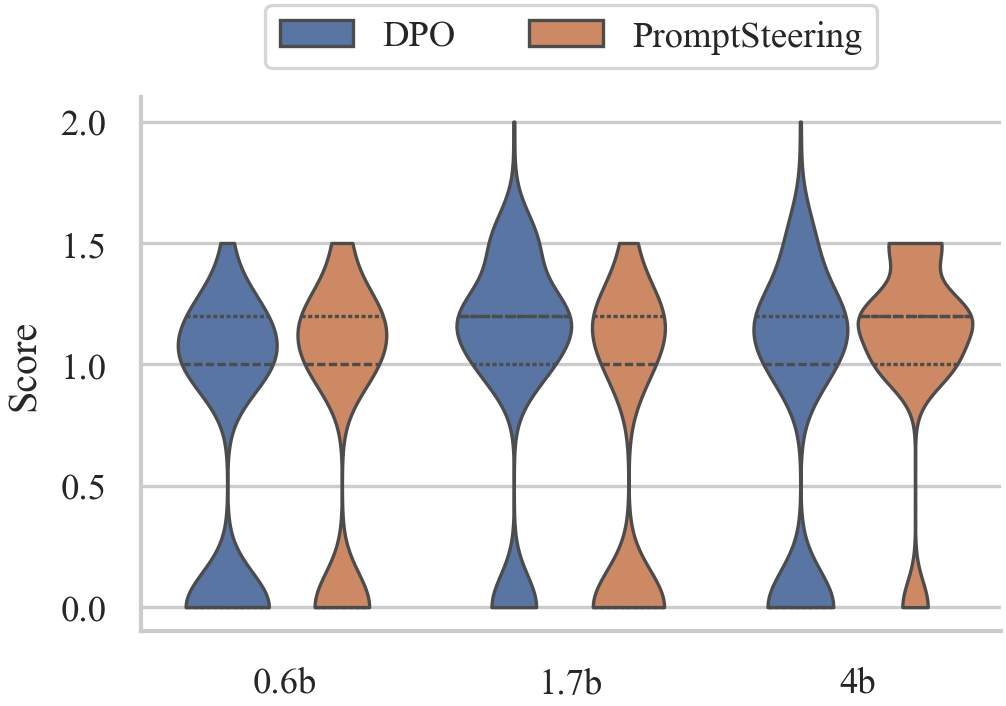

In [12]:
# Rebuild qwen_df with model/method metadata if it is not already in plotting shape.
if 'qwen_df' not in globals() or not {'Model', 'Method', 'DPO_LMJudgeEvaluator'}.issubset(qwen_df.columns):
    method_labels = {
        'dpo': 'DPO',
        'no_grad': 'PromptSteering',
    }
    qwen_frames = []

    for fp in find_inference_parquet_paths('./main_results/T1-results'):
        parts = str(fp).split('/')
        model = parts[2]
        model_size = parts[3]
        method = parts[4]

        if model != 'qwen3' or method not in method_labels:
            continue

        temp = pd.read_parquet(str(fp)).copy()
        temp['Model'] = model_size
        temp['Method'] = method_labels[method]
        temp['DPO_LMJudgeEvaluator'] = temp['PromptSteering_LMJudgeEvaluator']
        temp['OpenAI Score'] = temp['PromptSteering_LMJudgeEvaluator']
        qwen_frames.append(temp)

    qwen_df = pd.concat(qwen_frames, ignore_index=True)

if 'OpenAI Score' not in qwen_df.columns:
    qwen_df = qwen_df.copy()
    source_col = (
        'PromptSteering_LMJudgeEvaluator'
        if 'PromptSteering_LMJudgeEvaluator' in qwen_df.columns
        else 'DPO_LMJudgeEvaluator'
    )
    qwen_df['OpenAI Score'] = qwen_df[source_col]

plot_df = qwen_df.copy().dropna(subset=['OpenAI Score'])


def qwen_size_key(value: str) -> tuple[float, str]:
    numeric = ''.join(ch for ch in value if ch.isdigit() or ch == '.')
    return (float(numeric), value)


model_order = sorted(plot_df['Model'].unique(), key=qwen_size_key)
method_order = [m for m in ['DPO', 'PromptSteering'] if m in plot_df['Method'].unique()]

emnlp_rc = globals().get('EMNLP_RC')
plt.rcParams.update(emnlp_rc)
sns.set_theme(style='whitegrid', context='paper', font='serif')

fig, ax = plt.subplots(figsize=(3.4, 2.4), constrained_layout=True)
sns.violinplot(
    data=plot_df,
    x='Model',
    y='OpenAI Score',
    hue='Method',
    order=model_order,
    hue_order=method_order,
    inner='quartile',
    cut=0,
    linewidth=0.8,
    ax=ax,
)
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.legend(
    # title='Method',
    frameon=True,
    ncol=len(method_order),
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
)
sns.despine(ax=ax)

fig.savefig(
    "qwen_violin_plot.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300
)

plt.show()

Mean and variance by setting, method, and score type:


,Setting,Method,Score_Type,Mean,Variance,N,Std
6,2B L10,LAT,Concept,0.1488,0.1292,840,0.3594
8,2B L10,LAT,Instruction,0.5869,0.7505,840,0.8663
7,2B L10,LAT,Fluency,0.3488,0.2942,840,0.5424
15,2B L10,PCA,Concept,0.1429,0.1274,840,0.3569
17,2B L10,PCA,Instruction,0.4833,0.6553,840,0.8095
...,...,...,...,...,...,...,...
65,8B L20,PromptSteering,Instruction,1.7988,0.1704,840,0.4128
64,8B L20,PromptSteering,Fluency,1.1024,0.1063,840,0.3261
48,8B L20,DPO,Concept,1.3345,0.3659,840,0.6049
50,8B L20,DPO,Instruction,1.4214,0.5397,840,0.7346



Means:


/var/folders/dr/6dv3_zvd16sdmw4zwm1q5rxc0000gp/T/ipykernel_7689/1603109643.py:62: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mean_wide = stats_df.pivot_table(
/var/folders/dr/6dv3_zvd16sdmw4zwm1q5rxc0000gp/T/ipykernel_7689/1603109643.py:65: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  var_wide = stats_df.pivot_table(


Score_Type              Concept  Instruction  Fluency
Setting Method                                       
2B L10  LAT              0.1488       0.5869   0.3488
        PCA              0.1429       0.4833   0.2786
        SAE              0.2071       1.5060   0.9214
        DiffMean         0.3857       1.1012   0.6917
        LoRA             0.5857       1.7976   1.2845
        LoReFT           0.6524       1.6750   1.2393
        PromptSteering   0.7357       1.7714   1.0583
        DPO              1.2060       1.3107   1.2798
2B L20  LAT              0.3595       0.6833   0.3060
        PCA              0.3333       0.7190   0.3190
        SAE              0.1952       1.4119   0.7738
        DiffMean         0.3071       0.9643   0.4619
        LoRA             0.5012       1.7667   1.3190
        LoReFT           0.5476       1.6619   1.2929
        PromptSteering   0.6286       1.7750   1.0690
        DPO              1.1048       1.3524   1.3226
9B L20  LAT              0.0250       1.9143   1.1940
        PCA              0.0286       1.9214   1.2179
        SAE              0.0893       1.8119   1.1738
        DiffMean         0.4119       1.0298   0.6643
        LoRA             0.5583       1.7476   1.3405
        LoReFT           0.8000       1.6071   1.2821
        PromptSteering   1.0250       1.8000   1.1202
        DPO              1.3286       1.4357   1.1952
9B L31  LAT              0.0762       1.9179   1.2310
        PCA              0.0833       1.9298   1.1905
        SAE              0.0905       1.8131   1.1000
        DiffMean         0.3786       1.0024   0.4976
        LoRA             0.4417       1.8643   1.3000
        LoReFT           0.6310       1.7500   1.1964
        PromptSteering   1.0488       1.8976   1.1476
        DPO              1.4155       1.4798   1.1679
8B L20  LAT              0.0500       0.2869   0.0905
        PCA              0.0786       0.3202   0.1107
        DiffMean         0.3036       0.4798   0.2250
        LoReFT           0.7583       1.7512   1.3476
        PromptSteering   1.2226       1.7988   1.1024
        DPO              1.3345       1.4214   1.0786


Variances:


Score_Type              Concept  Instruction  Fluency
Setting Method                                       
2B L10  LAT              0.1292       0.7505   0.2942
        PCA              0.1274       0.6553   0.2465
        SAE              0.2073       0.6197   0.2346
        DiffMean         0.2777       0.8467   0.3470
        LoRA             0.5719       0.2450   0.2229
        LoReFT           0.5441       0.2983   0.2538
        PromptSteering   0.4235       0.2051   0.0598
        DPO              0.3926       0.5219   0.3471
2B L20  LAT              0.2401       0.7673   0.2507
        PCA              0.2296       0.7911   0.2485
        SAE              0.1978       0.7026   0.3063
        DiffMean         0.2250       0.8569   0.3084
        LoRA             0.3909       0.2077   0.2533
        LoReFT           0.4077       0.3242   0.3051
        PromptSteering   0.4245       0.2056   0.0667
        DPO              0.4038       0.5503   0.3022
9B L20  LAT              0.0244       0.1023   0.2233
        PCA              0.0278       0.0963   0.2207
        SAE              0.0862       0.2697   0.2677
        DiffMean         0.2664       0.8942   0.4783
        LoRA             0.4543       0.2604   0.2439
        LoReFT           0.5082       0.3699   0.2671
        PromptSteering   0.4106       0.1840   0.1059
        DPO              0.3568       0.5346   0.3337
9B L31  LAT              0.1038       0.0969   0.1945
        PCA              0.1099       0.0797   0.1973
        SAE              0.1181       0.2594   0.2832
        DiffMean         0.2784       0.8868   0.3790
        LoRA             0.4471       0.1460   0.2579
        LoReFT           0.5049       0.2569   0.2844
        PromptSteering   0.4279       0.0944   0.1284
        DPO              0.3051       0.5359   0.3329
8B L20  LAT              0.0499       0.4456   0.0967
        PCA              0.0773       0.4682   0.1200
        DiffMean         0.2593       0.6504   0.2246
        LoReFT           0.4743       0.2277   0.2485
        PromptSteering   0.3926       0.1704   0.1063
        DPO              0.3659       0.5397   0.3085

Saved figures/main_result/rating_mean_2B_L10.pdf


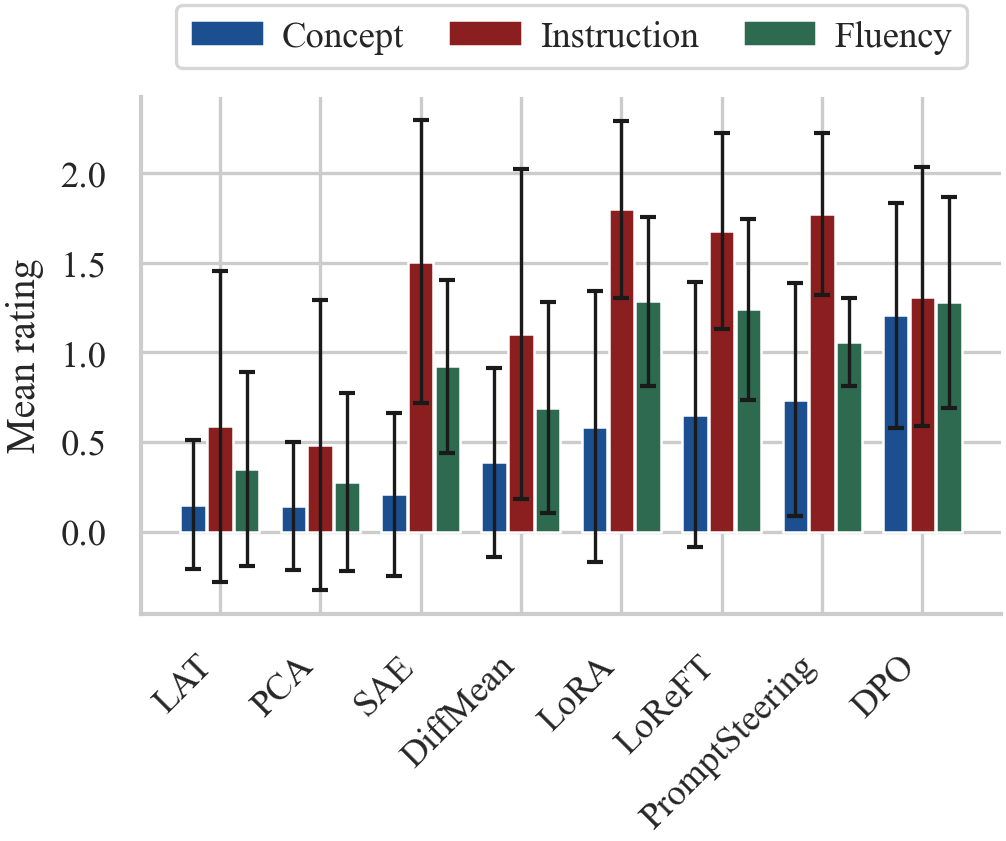

Saved figures/main_result/rating_mean_2B_L20.pdf


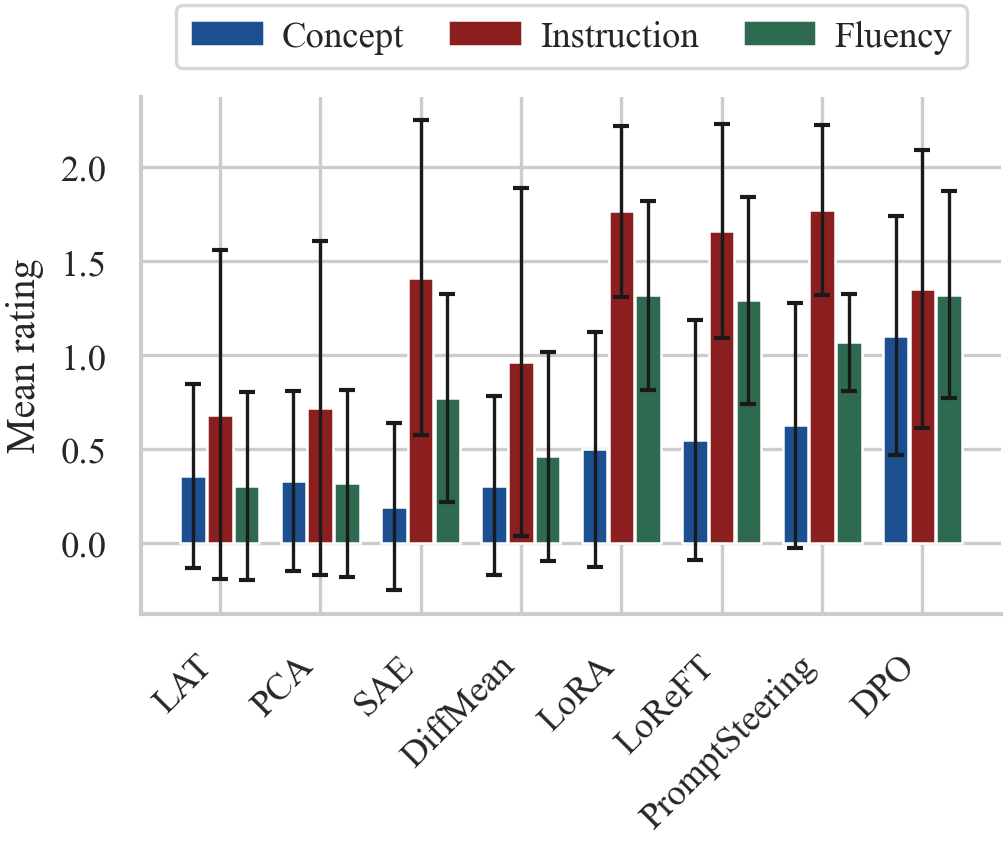

Saved figures/main_result/rating_mean_9B_L20.pdf


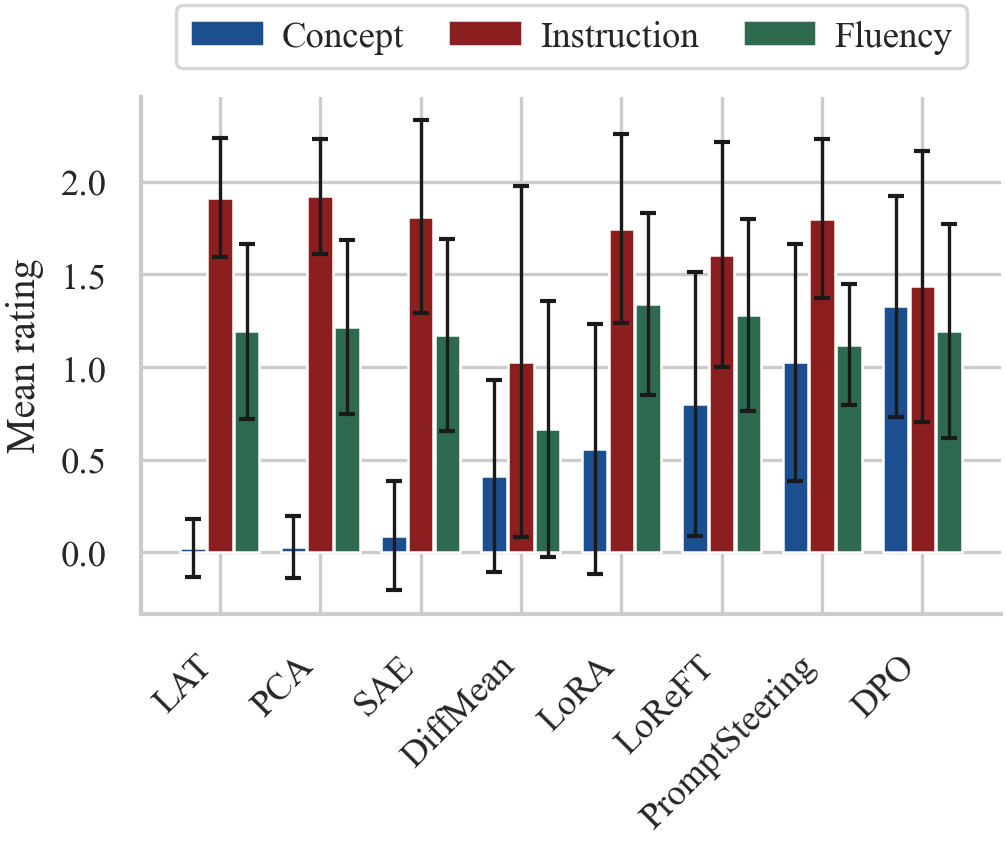

Saved figures/main_result/rating_mean_9B_L31.pdf


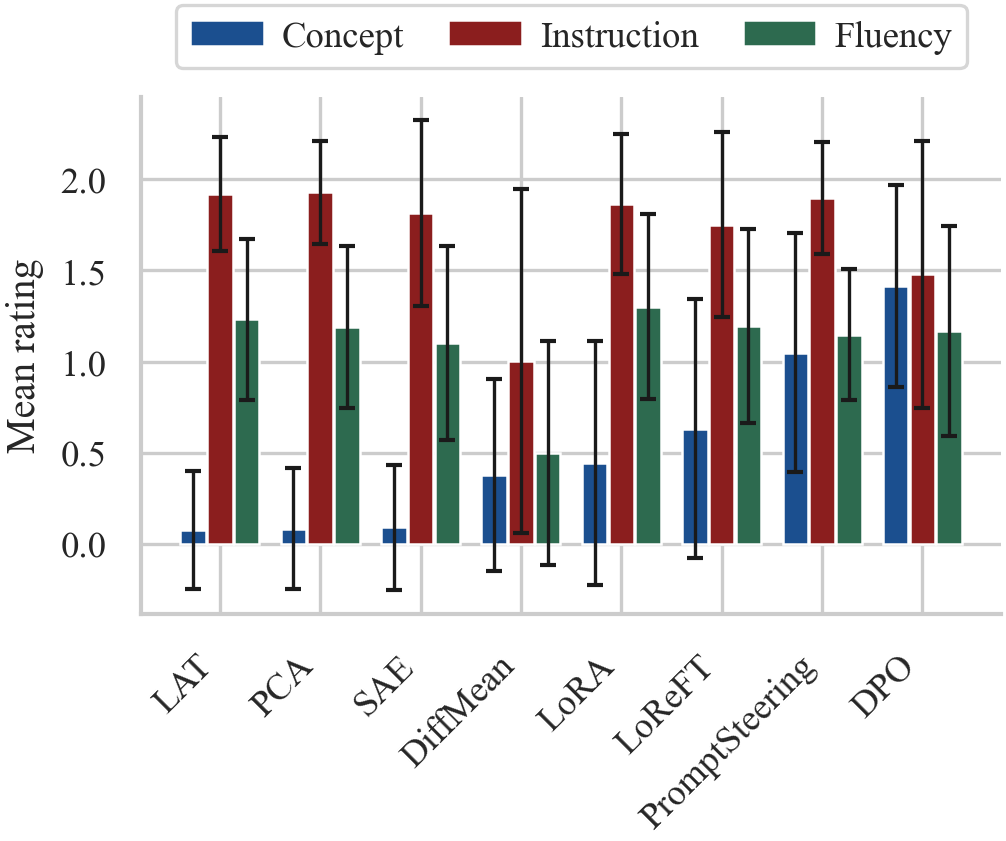

Saved figures/main_result/rating_mean_8B_L20.pdf


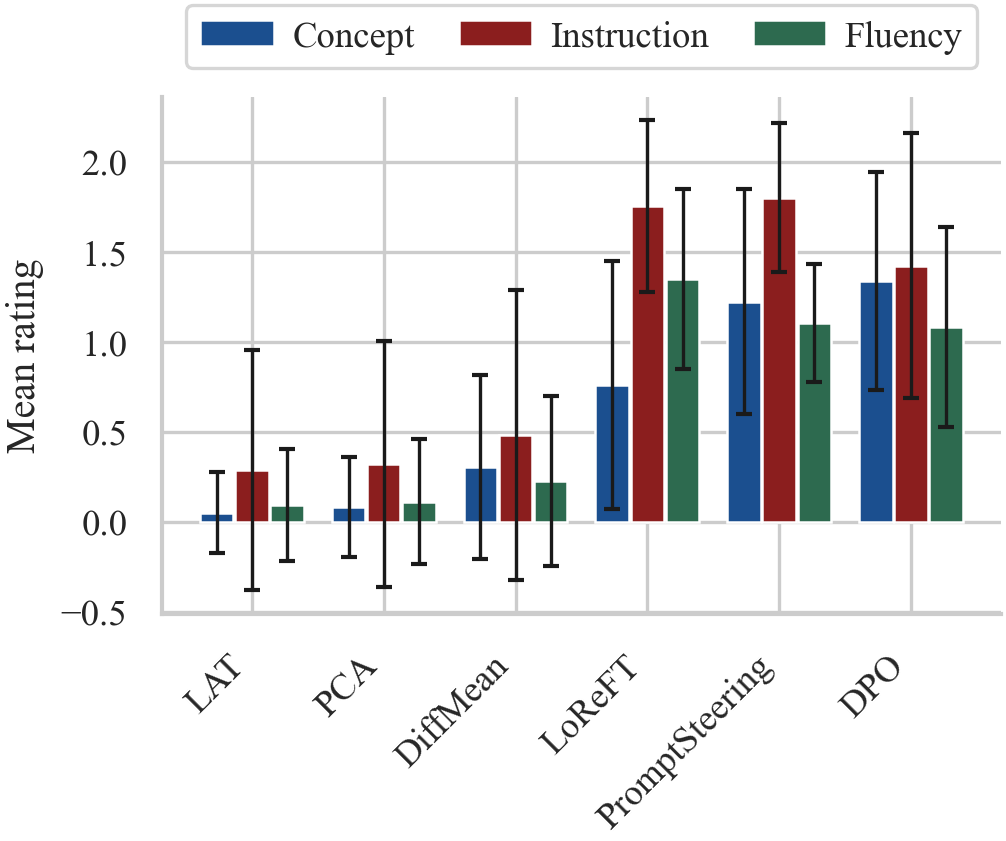

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import seaborn as sns


plt.rcParams.update(EMNLP_RC)
sns.set_theme(style='whitegrid', context='paper', font='serif')

FIG_DIR = Path('figures/main_result')
FIG_DIR.mkdir(parents=True, exist_ok=True)

SCORE_METRICS = [
    ('Score_Concept', 'Concept'),
    ('Score_Insturction', 'Instruction'),
    ('Score_Fluency', 'Fluency'),
]
SCORE_PALETTE = {
    'Concept': '#1b4f8f',
    'Instruction': '#8b1e1e',
    'Fluency': '#2d6a4f',
}

plot_df = result_df.copy()
plot_df['Method'] = plot_df['Method'].replace({'GemmaScopeSAE': 'SAE'})
plot_df['Setting'] = plot_df.apply(
    lambda r: COLUMN_MAP.get((r['Model'], r['Layer'])), axis=1
)
plot_df = plot_df.dropna(subset=['Setting'])

long_df = plot_df.melt(
    id_vars=['Method', 'Model', 'Layer', 'Setting'],
    value_vars=[c for c, _ in SCORE_METRICS],
    var_name='Score_Type',
    value_name='Score',
)
long_df['Score_Type'] = long_df['Score_Type'].map(dict(SCORE_METRICS))
long_df['Score'] = pd.to_numeric(long_df['Score'], errors='coerce')

settings = [c for c in LATEX_COLUMNS[:-1] if c in long_df['Setting'].unique()]
methods_present = [m for m in METHOD_ORDER if m in long_df['Method'].unique()]
score_types = [label for _, label in SCORE_METRICS]

stats_df = (
    long_df.groupby(['Setting', 'Method', 'Score_Type'], observed=True)
    .agg(Mean=('Score', 'mean'), Variance=('Score', 'var'), N=('Score', 'count'))
    .reset_index()
)
stats_df['Std'] = stats_df['Variance'].pow(0.5)
setting_cat = pd.Categorical(stats_df['Setting'], categories=settings, ordered=True)
method_cat = pd.Categorical(stats_df['Method'], categories=methods_present, ordered=True)
metric_cat = pd.Categorical(stats_df['Score_Type'], categories=score_types, ordered=True)
stats_df = stats_df.assign(
    Setting=setting_cat, Method=method_cat, Score_Type=metric_cat
).sort_values(['Setting', 'Method', 'Score_Type'])

print('Mean and variance by setting, method, and score type:')
display(stats_df.round(4))

mean_wide = stats_df.pivot_table(
    index=['Setting', 'Method'], columns='Score_Type', values='Mean'
).reindex(columns=score_types)
var_wide = stats_df.pivot_table(
    index=['Setting', 'Method'], columns='Score_Type', values='Variance'
).reindex(columns=score_types)
print('\nMeans:')
display(mean_wide.round(4))
print('\nVariances:')
display(var_wide.round(4))


def methods_for_setting(setting_df):
    present = set(setting_df['Method'].unique())
    return [m for m in METHOD_ORDER if m in present]


def plot_mean_variance(ax, data, *, methods, metrics, palette):
    grouped = (
        data.groupby(['Method', 'Score_Type'], observed=True)['Score']
        .agg(['mean', 'var'])
        .reset_index()
    )
    n_metrics = len(metrics)
    bar_width = 0.8 / n_metrics
    x = np.arange(len(methods))

    for i, metric in enumerate(metrics):
        offsets = (i - (n_metrics - 1) / 2) * bar_width
        means, yerr = [], []
        for method in methods:
            row = grouped[
                (grouped['Method'] == method) & (grouped['Score_Type'] == metric)
            ]
            if row.empty:
                means.append(np.nan)
                yerr.append(0)
            else:
                means.append(row['mean'].iloc[0])
                var = row['var'].iloc[0]
                yerr.append(np.sqrt(var) if pd.notna(var) else 0)
        ax.bar(
            x + offsets,
            means,
            width=bar_width * 0.95,
            yerr=yerr,
            capsize=2,
            color=palette[metric],
            edgecolor='white',
            linewidth=0.6,
            error_kw={'elinewidth': 0.8},
        )

    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=45, ha='right')
    # ax.set_xlabel('Method')
    ax.set_ylabel('Mean rating')
    handles = [
        Patch(facecolor=palette[m], edgecolor='white', linewidth=0.6, label=m)
        for m in metrics
    ]
    ax.legend(
        handles=handles,
        loc='lower center',
        bbox_to_anchor=(0.5, 1.02),
        ncol=len(metrics),
        frameon=True,
        columnspacing=1.2,
        handletextpad=0.5,
    )
    sns.despine(ax=ax)


for setting in settings:
    subset = long_df[long_df['Setting'] == setting]
    methods = methods_for_setting(subset)
    fig_w = max(3.4, 0.42 * len(methods))
    fig, ax = plt.subplots(figsize=(fig_w, 2.85), constrained_layout=True)
    plot_mean_variance(
        ax,
        subset,
        methods=methods,
        metrics=score_types,
        palette=SCORE_PALETTE,
    )
    pdf_path = FIG_DIR / f'rating_mean_{setting.replace(" ", "_")}.pdf'
    fig.savefig(pdf_path, format='pdf')
    print(f'Saved {pdf_path}')
    plt.show()
    plt.close(fig)